## Setup and Load Model

In [3]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

class GuitarChordClassifier(nn.Module):
    def __init__(self, num_classes=5):
        super(GuitarChordClassifier, self).__init__()
        self.base_model = timm.create_model('inception_resnet_v2', pretrained=False, num_classes=0)
        in_features = self.base_model.num_features
        
        self.custom_tail = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_features, 256),  
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.base_model.forward_features(x)
        output = self.custom_tail(features)
        return output

model = GuitarChordClassifier(num_classes=5).to(device)

WEIGHTS_PATH = 'chord_classifier_weights_test_new.pth' 
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
model.eval()

print("Model successfully loaded and ready for testing!")

/Users/jasraj/Desktop/CV_Proj/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model successfully loaded and ready for testing!


## Loading Data

In [4]:
TEST_DATA_DIR = Path("dataset/fd_processed/") 

CLASS_NAMES = ['C', 'D', 'Em', 'F','G'] 
CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}

class SampleWiseCenter(object):
    def __call__(self, tensor):
        return tensor - tensor.mean()

test_transforms = transforms.Compose([
    transforms.Resize((229, 229)),
    transforms.ToTensor(),
    SampleWiseCenter(),

])

person_metrics = {}
all_true_labels = []
all_pred_labels = []

print("Beginning Extensive Testing...\n")

for person_dir in TEST_DATA_DIR.iterdir():
    if not person_dir.is_dir(): continue
    
    person_name = person_dir.name
    person_metrics[person_name] = {'correct': 0, 'total': 0, 'classes': {c: {'correct': 0, 'total': 0} for c in CLASS_NAMES}}
    
    for chord_dir in person_dir.iterdir():
        if not chord_dir.is_dir() or chord_dir.name not in CLASS_NAMES: continue
            
        chord_name = chord_dir.name
        true_class_idx = CLASS_TO_IDX[chord_name]
        
        for img_path in chord_dir.glob('*.*'):
            if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png']: continue
                
            try:
                img = Image.open(img_path).convert('RGB')
                input_tensor = test_transforms(img).unsqueeze(0).to(device)
                
                # predict
                with torch.no_grad():
                    # outputs = model(input_tensor)
                    # _, predicted_idx = torch.max(outputs, 1)
                    # predicted_idx = predicted_idx.item()
                    outputs = model(input_tensor)
                    probabilities = torch.softmax(outputs, dim=1)
                    confidence, predicted_idx = torch.max(probabilities, 1)
                
                if confidence.item() < 0.5:
                    # flag as uncertain
                    pass
                is_correct = (predicted_idx == true_class_idx)
                
                person_metrics[person_name]['total'] += 1
                person_metrics[person_name]['classes'][chord_name]['total'] += 1
                
                if is_correct:
                    person_metrics[person_name]['correct'] += 1
                    person_metrics[person_name]['classes'][chord_name]['correct'] += 1
                    
                all_true_labels.append(true_class_idx)
                all_pred_labels.append(predicted_idx)
                
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

print("Testing Complete!")

Beginning Extensive Testing...

Testing Complete!


## Results

In [5]:
print("==================================================")
print("         MODEL REPORT              ")
print("==================================================\n")

total_correct = 0
total_images = 0

for person, data in person_metrics.items():
    if data['total'] == 0: continue
        
    p_acc = (data['correct'] / data['total']) * 100
    print(f"  Subject: {person}")
    print(f"   Overall Accuracy: {p_acc:.2f}% ({data['correct']}/{data['total']})")
    
    for chord in CLASS_NAMES:
        c_data = data['classes'][chord]
        if c_data['total'] > 0:
            c_acc = (c_data['correct'] / c_data['total']) * 100
            print(f"      - {chord}: {c_acc:.2f}% ({c_data['correct']}/{c_data['total']})")
    print("-" * 50)
    
    total_correct += data['correct']
    total_images += data['total']

if total_images > 0:
    global_acc = (total_correct / total_images) * 100
    print(f"\n GLOBAL TEST ACCURACY: {global_acc:.2f}% ({total_correct}/{total_images})")

         MODEL REPORT              

  Subject: goodguitarist
   Overall Accuracy: 83.33% (20/24)
      - C: 80.00% (4/5)
      - D: 100.00% (5/5)
      - Em: 60.00% (3/5)
      - F: 100.00% (5/5)
      - G: 75.00% (3/4)
--------------------------------------------------
  Subject: LaurenBateman
   Overall Accuracy: 100.00% (33/33)
      - C: 100.00% (6/6)
      - D: 100.00% (6/6)
      - Em: 100.00% (6/6)
      - F: 100.00% (7/7)
      - G: 100.00% (8/8)
--------------------------------------------------
  Subject: sarasingssongs
   Overall Accuracy: 92.86% (26/28)
      - C: 100.00% (5/5)
      - D: 100.00% (6/6)
      - Em: 83.33% (5/6)
      - F: 100.00% (5/5)
      - G: 83.33% (5/6)
--------------------------------------------------
  Subject: Miscellaneous
   Overall Accuracy: 80.77% (63/78)
      - C: 86.67% (13/15)
      - D: 93.75% (15/16)
      - Em: 56.25% (9/16)
      - F: 80.00% (12/15)
      - G: 87.50% (14/16)
--------------------------------------------------
  Subject:

## Confusion Matrix

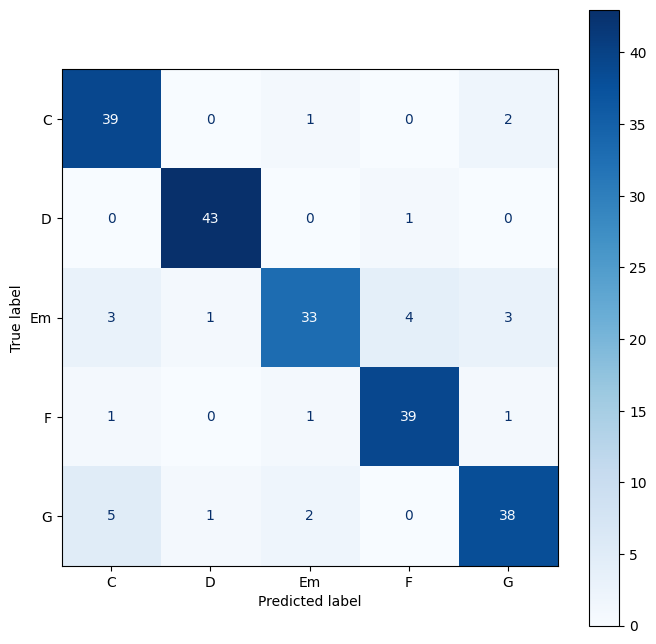

In [6]:
import numpy as np

all_pred_labels = [p.cpu().item() if hasattr(p, "cpu") else p for p in all_pred_labels]

cm = confusion_matrix(
    np.array(all_true_labels),
    np.array(all_pred_labels)
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

# plt.title('Global Test Dataset Confusion Matrix')
plt.show()

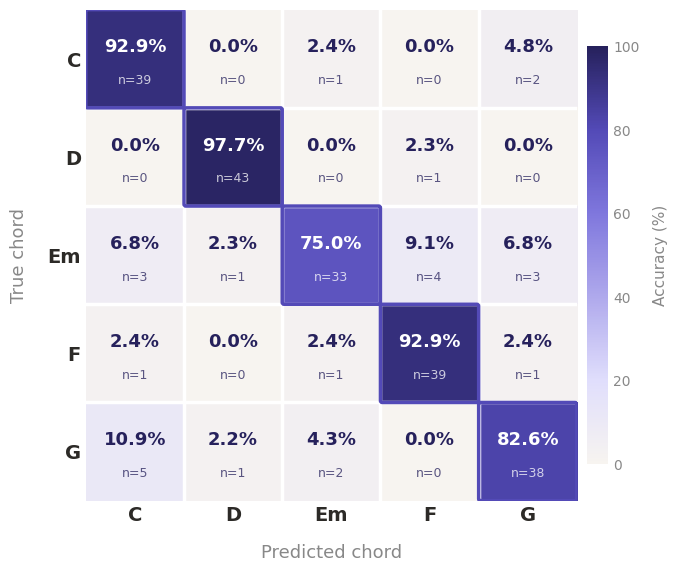

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ["C", "D", "Em", "F", "G"]

all_pred_labels = [p.cpu().item() if hasattr(p, "cpu") else p for p in all_pred_labels]

cm = confusion_matrix(
    np.array(all_true_labels),
    np.array(all_pred_labels)
)

# ── normalise for % display ──────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

# ── custom warm cream → deep purple colormap ─────────────────────────
cmap = LinearSegmentedColormap.from_list(
    "poster",
    ["#F7F4F0", "#E0DEFC", "#AFA9EC", "#7F77DD", "#534AB7", "#26215C"],
    N=256
)

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=100, aspect="equal")

# ── cell text ────────────────────────────────────────────────────────
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        val_pct = cm_norm[i, j]
        val_raw = cm[i, j]
        # white text on dark cells, dark on light
        text_color = "#FFFFFF" if val_pct > 55 else "#26215C"
        # percentage on top line, raw count smaller below
        ax.text(j, i - 0.12, f"{val_pct:.1f}%",
                ha="center", va="center",
                fontsize=13, fontweight="bold",
                color=text_color, fontfamily="sans-serif")
        ax.text(j, i + 0.22, f"n={val_raw}",
                ha="center", va="center",
                fontsize=9, color=text_color,
                alpha=0.75, fontfamily="sans-serif")

# ── axes styling ─────────────────────────────────────────────────────
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, fontsize=14, fontweight="600",
                   color="#2c2a27", fontfamily="sans-serif")
ax.set_yticklabels(CLASS_NAMES, fontsize=14, fontweight="600",
                   color="#2c2a27", fontfamily="sans-serif")
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

ax.set_xlabel("Predicted chord", fontsize=13, labelpad=14,
              color="#888", fontfamily="sans-serif")
ax.set_ylabel("True chord", fontsize=13, labelpad=14,
              color="#888", fontfamily="sans-serif")

# ── remove all spines ────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

# ── subtle grid lines between cells ──────────────────────────────────
n = len(CLASS_NAMES)
for k in range(1, n):
    ax.axhline(k - 0.5, color="#ffffff", linewidth=2.5)
    ax.axvline(k - 0.5, color="#ffffff", linewidth=2.5)

# ── highlight diagonal (correct predictions) ─────────────────────────
for i in range(n):
    rect = patches.FancyBboxPatch(
        (i - 0.48, i - 0.48), 0.96, 0.96,
        boxstyle="round,pad=0.02",
        linewidth=2.5,
        edgecolor="#534AB7",
        facecolor="none",
        zorder=3
    )
    ax.add_patch(rect)

# ── colorbar ─────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.ax.set_ylabel("Accuracy (%)", fontsize=11, color="#888",
                   fontfamily="sans-serif", labelpad=10)
cbar.ax.tick_params(labelsize=10, colors="#888", length=0)
cbar.outline.set_visible(False)

# ── overall accuracy watermark ────────────────────────────────────────
overall_acc = np.trace(cm) / cm.sum() * 100
# ax.text(0.98, 1.03, f"Overall accuracy: {overall_acc:.1f}%",
#         transform=ax.transAxes, ha="right", va="bottom",
#         fontsize=12, fontweight="bold", color="#534AB7",
#         fontfamily="sans-serif")

plt.tight_layout(pad=1.5)
plt.savefig("confusion_matrix_poster.png", dpi=300,
            bbox_inches="tight", facecolor="#F7F5F2")
plt.show()